# Does the court surface affect the number of aces?

### It imports two libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#### It reads match statistics and ground type information, calculates the total number of aces for each match
#### and merges this data with the ground type; matches with an unspecified ground type are removed

In [2]:
IN_DIR = "cleaned_data"
stats_df =pd.read_parquet(f"{IN_DIR}/statistics.parquet")
tour = pd.read_parquet(f"{IN_DIR}/tournament.parquet")[["match_id", "ground_type"]]

aces = stats_df[(stats_df["statistic_name"] == "aces") & (stats_df["period"] == "ALL")][["match_id", "home_value", "away_value"]].copy()
aces["total_aces"] = aces.home_value + aces.away_value

m = aces.merge(tour, on="match_id", how="inner").dropna(subset=["ground_type"])

#### The raw and scattered `ground_type` categories (such as 'Red clay indoor') are consolidated into five main groups
#### then, the mean or median number of aces for each group is calculated and printed in sorted order

In [3]:
def simplify(g):
    g = str(g).lower()
    if "clay" in g: return "Clay"
    if "hardcourt" in g: return "Hardcourt"
    if "grass" in g: return "Grass"
    if "carpet" in g: return "Carpet"
    if "synthetic" in g: return "Synthetic"
    return g

m["surface_group"] = m.ground_type.apply(simplify)

summary = m.groupby("surface_group")["total_aces"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
print(summary)

               count       mean  median
surface_group                          
Carpet           120  11.091667    10.0
Grass            156   9.256410     7.5
Hardcourt       7228   6.138213     5.0
Synthetic         78   3.243590     2.0
Clay            3654   3.215654     2.0


#### A bar chart with five distinct colors is plotted for the five soil types; both the mean and the sample size (n) are displayed on each bar so that the reader can immediately identify which groups have small sample sizes

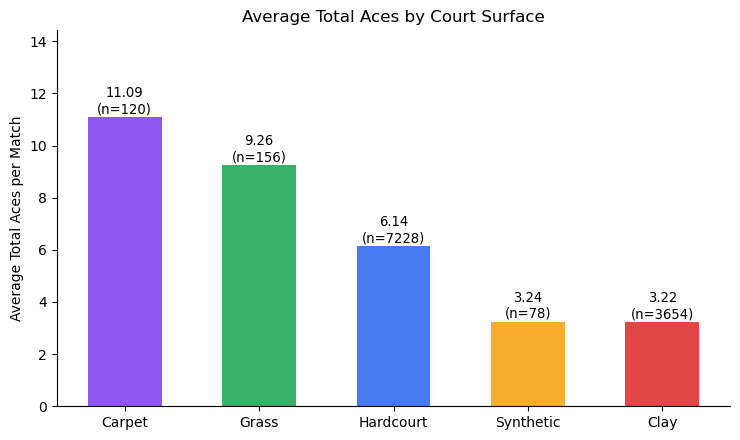

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
labels = list(summary.index)
vals = summary["mean"].values
counts = summary["count"].values
colors_list = ["#7c3aed", "#16a34a", "#2563eb", "#f59e0b", "#dc2626"]

bars = ax.bar(labels, vals, color=colors_list[:len(labels)], alpha=0.85, width=0.55)
for b, v, c in zip(bars, vals, counts):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.15, f"{v:.2f}\n(n={c})", ha="center", fontsize=9.5)
ax.set_title("Average Total Aces by Court Surface")
ax.set_ylabel("Average Total Aces per Match")
ax.set_ylim(0, max(vals) * 1.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("charts/aces_by_surface.png", dpi=170)
plt.show()

Fast courts produce significantly more aces than slow courts—a difference of nearly 3.5 times between the highest and lowest rates.

This pattern aligns perfectly with the physics of tennis: on clay, the ball moves more slowly and bounces higher, making service returns easier; conversely, carpet and grass surfaces maintain ball speed, thereby increasing the likelihood of aces.

Consequently, the court surface plays a major role (grass and carpet yield the highest number of aces, while synthetic and clay yield the lowest).

(To ensure statistical significance, raw and fragmented surface categories—such as green clay and indoor red clay—were consolidated into five main groups: Hardcourt, Clay, Grass, Carpet, and Synthetic.)